In [2]:
import pandas as pd

df = pd.read_csv("SUPER MARKET DATA.csv.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (500, 13)
Columns:
['Invoice ID', 'Date', 'Branch', 'City', 'Customer Type', 'Gender', 'Product', 'Category', 'Quantity', 'Unit Price', 'Payment', 'Rating', 'Sales']


In [3]:
df.head()

,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,01-06-2026,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.8,228.52
1,INV0002,26-02-2026,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.9,601.65
2,INV0003,09-02-2026,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.4,171.84
3,INV0004,12-01-2026,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.5,336.54
4,INV0005,30-06-2026,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.1,652.85


In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nDataset Information:")
df.info()

Number of Rows: 500
Number of Columns: 13

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice ID     500 non-null    str    
 1   Date           500 non-null    str    
 2   Branch         500 non-null    str    
 3   City           500 non-null    str    
 4   Customer Type  500 non-null    str    
 5   Gender         500 non-null    str    
 6   Product        500 non-null    str    
 7   Category       500 non-null    str    
 8   Quantity       500 non-null    int64  
 9   Unit Price     500 non-null    float64
 10  Payment        500 non-null    str    
 11  Rating         500 non-null    float64
 12  Sales          500 non-null    float64
dtypes: float64(3), int64(1), str(9)
memory usage: 50.9 KB


In [5]:
df.columns = df.columns.str.strip()

print("Column Names:")
print(df.columns.tolist())

Column Names:
['Invoice ID', 'Date', 'Branch', 'City', 'Customer Type', 'Gender', 'Product', 'Category', 'Quantity', 'Unit Price', 'Payment', 'Rating', 'Sales']


In [6]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

Missing Values in Each Column:
Invoice ID       0
Date             0
Branch           0
City             0
Customer Type    0
Gender           0
Product          0
Category         0
Quantity         0
Unit Price       0
Payment          0
Rating           0
Sales            0
dtype: int64

Total Missing Values:
0


In [7]:
print("Number of Duplicate Rows:")
print(df.duplicated().sum())

Number of Duplicate Rows:
0


In [8]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (500, 13)


In [9]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df["Date"].head())
print("\nInvalid Dates:", df["Date"].isnull().sum())

0   2026-01-06
1          NaT
2   2026-09-02
3   2026-12-01
4          NaT
Name: Date, dtype: datetime64[us]

Invalid Dates: 291


In [10]:
numeric_columns = [
    "Quantity",
    "Unit Price",
    "Rating",
    "Sales"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print(df[numeric_columns].dtypes)

Quantity        int64
Unit Price    float64
Rating        float64
Sales         float64
dtype: object


In [11]:
print("Final Dataset Shape:", df.shape)

df.head()

Final Dataset Shape: (500, 13)


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-01-06,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.8,228.52
1,INV0002,NaT,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.9,601.65
2,INV0003,2026-09-02,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.4,171.84
3,INV0004,2026-12-01,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.5,336.54
4,INV0005,NaT,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.1,652.85


In [12]:
df["Calculated Sales"] = df["Quantity"] * df["Unit Price"]

df[
    [
        "Quantity",
        "Unit Price",
        "Sales",
        "Calculated Sales"
    ]
].head()

,Quantity,Unit Price,Sales,Calculated Sales
0,4,57.13,228.52,228.52
1,9,66.85,601.65,601.65
2,3,57.28,171.84,171.84
3,2,168.27,336.54,336.54
4,5,130.57,652.85,652.85


In [13]:
df["Sales Difference"] = (
    df["Sales"] - df["Calculated Sales"]
).abs()

print("Total Difference:",
      df["Sales Difference"].sum())

print("Maximum Difference:",
      df["Sales Difference"].max())

Total Difference: 8.071765478234738e-12
Maximum Difference: 4.547473508864641e-13


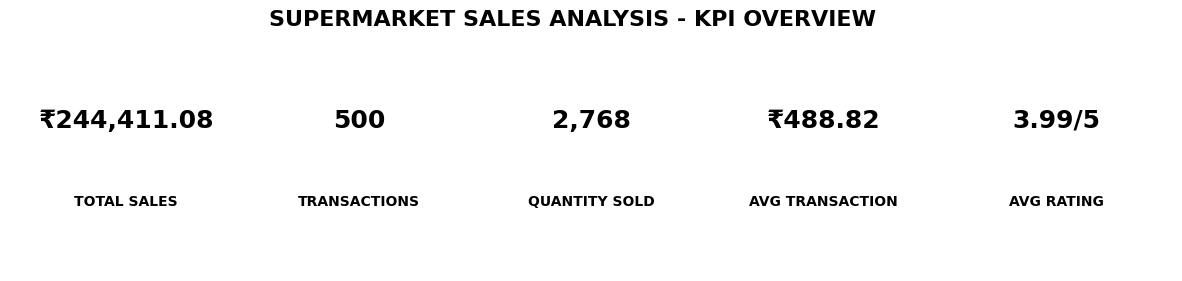

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 3))
ax.axis("off")

kpis = [
    ("TOTAL SALES", f"₹{total_sales:,.2f}"),
    ("TRANSACTIONS", f"{total_transactions:,}"),
    ("QUANTITY SOLD", f"{total_quantity:,}"),
    ("AVG TRANSACTION", f"₹{average_transaction:,.2f}"),
    ("AVG RATING", f"{average_rating:.2f}/5")
]

for i, (title, value) in enumerate(kpis):

    x = 0.1 + i * 0.2

    ax.text(
        x, 0.65,
        value,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold"
    )

    ax.text(
        x, 0.30,
        title,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.suptitle(
    "SUPERMARKET SALES ANALYSIS - KPI OVERVIEW",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [15]:
product_sales = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(product_sales)

Product
Cheese         27906.30
Coffee         27694.87
Shampoo        27497.48
Cooking Oil    21525.06
Tea            17681.59
Apples         17057.41
Face Wash      11946.85
Rice           11754.17
Cold Drink     10731.78
Eggs           10429.77
Chocolate       7250.65
Noodles         7191.24
Potato          6799.38
Bread           6516.10
Soap            6499.63
Bananas         6205.76
Chips           5833.45
Milk            5655.93
Tomato          4324.79
Biscuits        3908.87
Name: Sales, dtype: float64


In [16]:
top_product = product_sales.idxmax()
top_product_sales = product_sales.max()

print("Top Product:", top_product)
print("Top Product Sales: ₹", round(top_product_sales, 2))

Top Product: Cheese
Top Product Sales: ₹ 27906.3


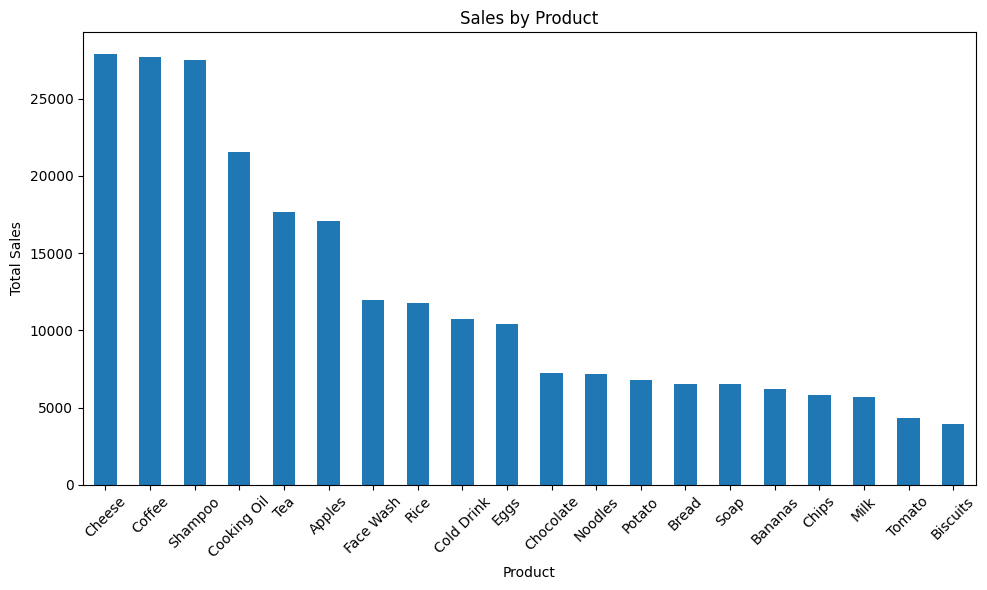

In [18]:
plt.figure(figsize=(10, 6))

product_sales.plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [19]:
branch_sales = (
    df.groupby("Branch")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(branch_sales)

Branch
C    72469.45
B    64116.26
D    55468.29
A    52357.08
Name: Sales, dtype: float64


In [20]:
best_branch = branch_sales.idxmax()
best_branch_sales = branch_sales.max()

print("Best Branch:", best_branch)
print("Best Branch Sales: ₹", round(best_branch_sales, 2))

Best Branch: C
Best Branch Sales: ₹ 72469.45


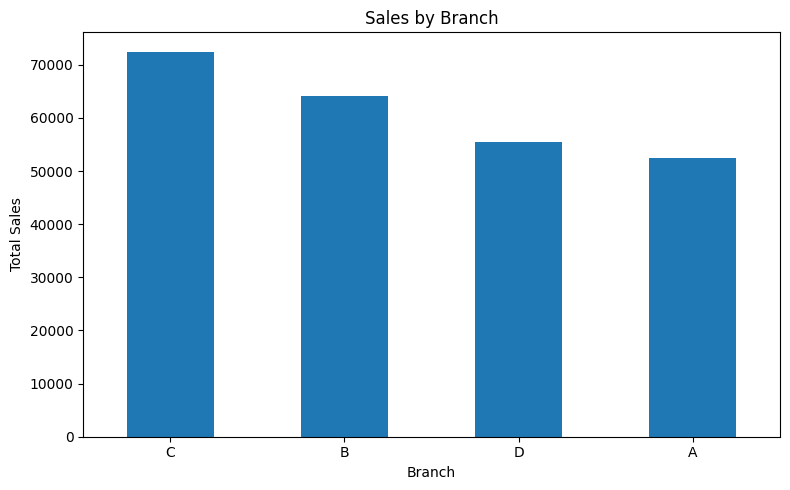

In [21]:
plt.figure(figsize=(8, 5))

branch_sales.plot(kind="bar")

plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [22]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Beverages        56108.24
Personal Care    45943.96
Dairy            43992.00
Grocery          40470.47
Fruits           23263.17
Snacks           16992.97
Vegetables       11124.17
Bakery            6516.10
Name: Sales, dtype: float64


In [23]:
top_category = category_sales.idxmax()
top_category_sales = category_sales.max()

print("Top Category:", top_category)
print("Top Category Sales: ₹", round(top_category_sales, 2))

Top Category: Beverages
Top Category Sales: ₹ 56108.24


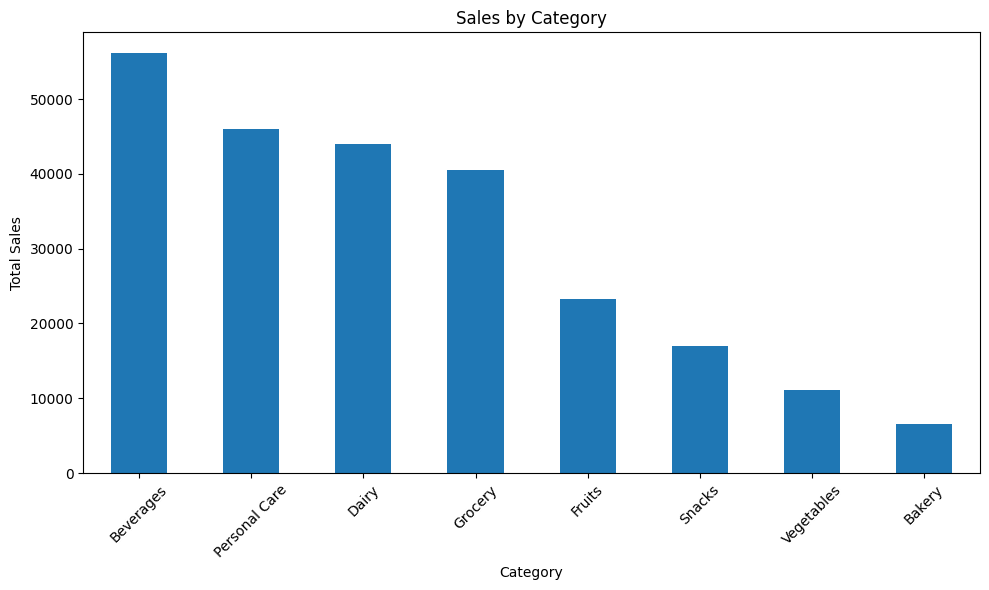

In [24]:
plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [25]:
payment_count = df["Payment"].value_counts()

print("Payment Method Usage:")
print(payment_count)

Payment Method Usage:
Payment
UPI            127
Net Banking    126
Card           125
Cash           122
Name: count, dtype: int64


In [26]:
popular_payment = payment_count.idxmax()
popular_payment_count = payment_count.max()

print("Most Used Payment Method:", popular_payment)
print("Number of Transactions:", popular_payment_count)

Most Used Payment Method: UPI
Number of Transactions: 127


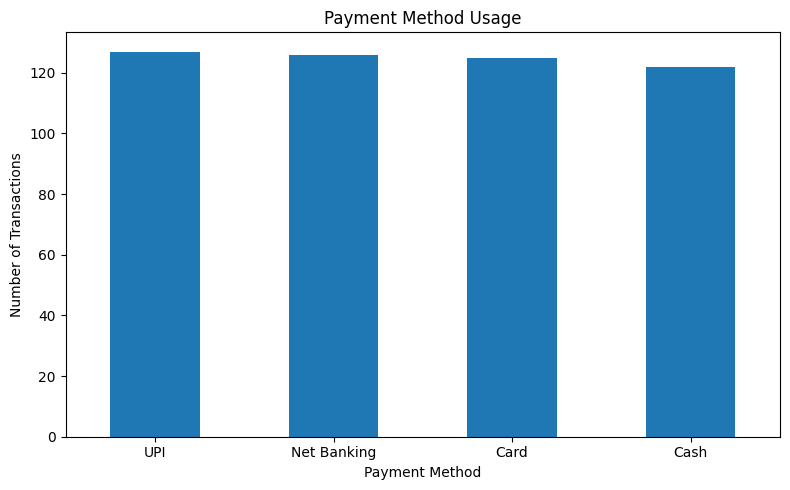

In [27]:
plt.figure(figsize=(8, 5))

payment_count.plot(kind="bar")

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [28]:
customer_type_sales = (
    df.groupby("Customer Type")["Sales"]
    .agg(["sum", "mean", "count"])
)

print(customer_type_sales)

                     sum        mean  count
Customer Type                              
Member         143009.30  483.139527    296
Normal         101401.78  497.067549    204


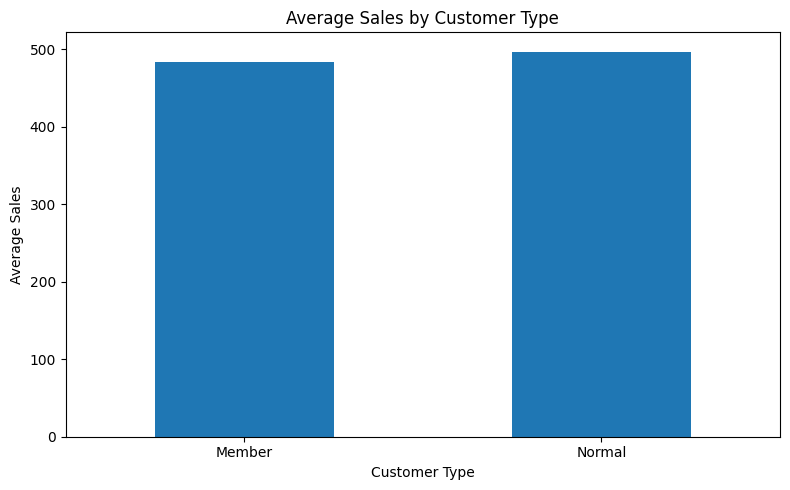

In [29]:
customer_average = (
    df.groupby("Customer Type")["Sales"]
    .mean()
)

plt.figure(figsize=(8, 5))

customer_average.plot(kind="bar")

plt.title("Average Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [30]:
customer_type_sales = (
    df.groupby("Customer Type")["Sales"]
    .agg(["sum", "mean", "count"])
)

print(customer_type_sales)

                     sum        mean  count
Customer Type                              
Member         143009.30  483.139527    296
Normal         101401.78  497.067549    204


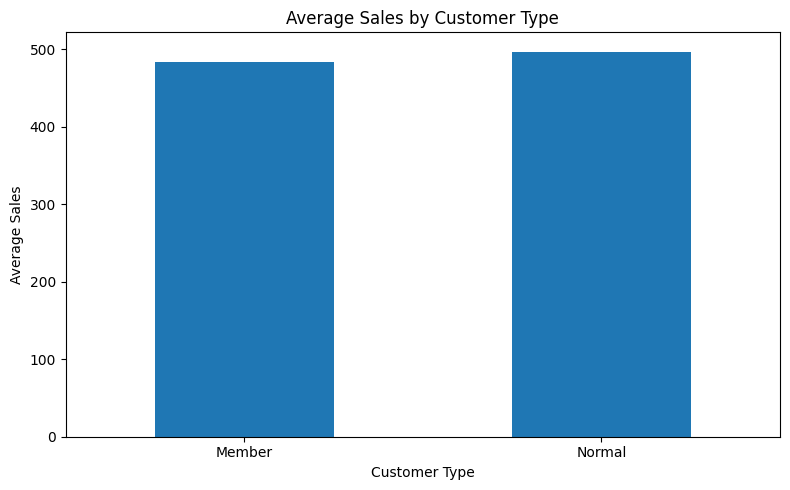

In [31]:
customer_average = (
    df.groupby("Customer Type")["Sales"]
    .mean()
)

plt.figure(figsize=(8, 5))

customer_average.plot(kind="bar")

plt.title("Average Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [32]:
city_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(city_sales)

City
Mumbai       72469.45
Delhi        64116.26
Bengaluru    55468.29
Jaipur       52357.08
Name: Sales, dtype: float64


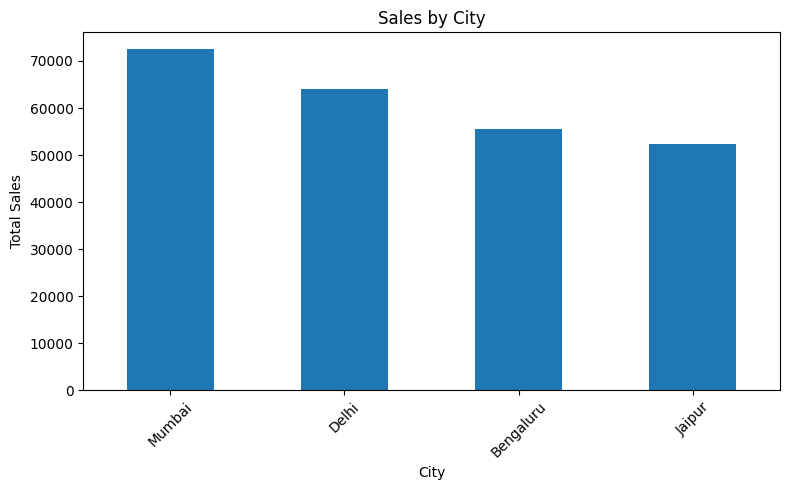

In [33]:
plt.figure(figsize=(8, 5))

city_sales.plot(kind="bar")

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [34]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
)

print(monthly_sales)

Month
2026-01    11425.34
2026-02    11116.07
2026-03     8741.34
2026-04     4105.35
2026-05     8407.87
2026-06     8508.94
2026-07     7233.77
2026-08     7157.73
2026-09     9715.08
2026-10     9743.16
2026-11     5814.79
2026-12    11602.25
Name: Sales, dtype: float64


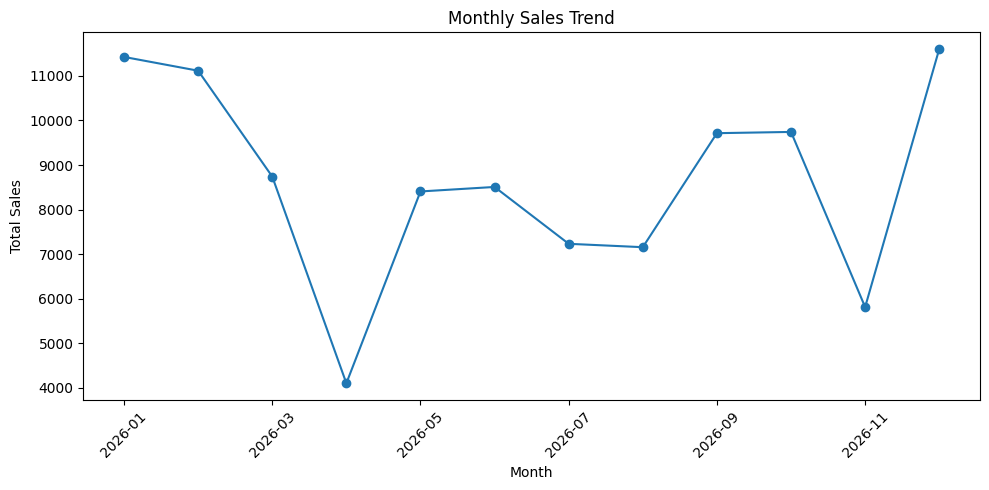

In [35]:
plt.figure(figsize=(10, 5))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [36]:
print("Average Rating:", round(df["Rating"].mean(), 2))

print("\nRating Statistics:")
print(df["Rating"].describe())

Average Rating: 3.99

Rating Statistics:
count    500.000000
mean       3.994400
std        0.574481
min        3.000000
25%        3.500000
50%        4.000000
75%        4.500000
max        5.000000
Name: Rating, dtype: float64


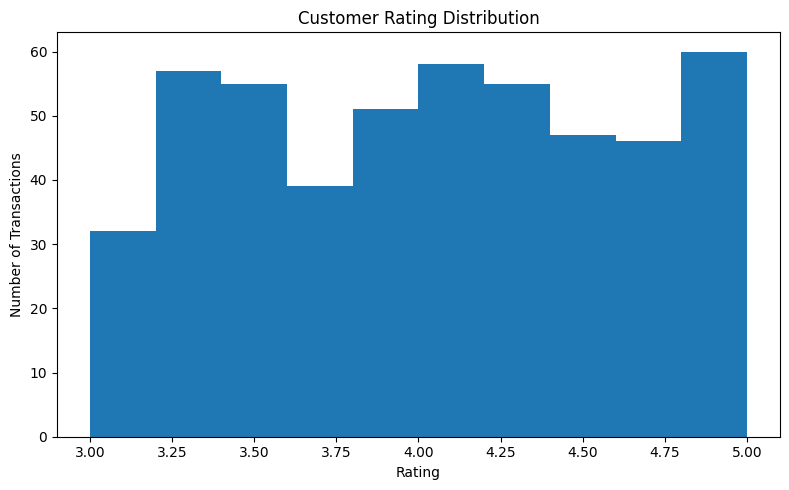

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(df["Rating"].dropna(), bins=10)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [38]:
quantity_by_product = (
    df.groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(quantity_by_product)

Product
Potato         194
Chips          168
Rice           167
Cold Drink     166
Bread          164
Coffee         153
Shampoo        152
Soap           147
Tea            146
Chocolate      145
Cooking Oil    142
Biscuits       130
Noodles        130
Cheese         126
Apples         119
Eggs           117
Bananas        104
Milk           102
Face Wash      100
Tomato          96
Name: Quantity, dtype: int64


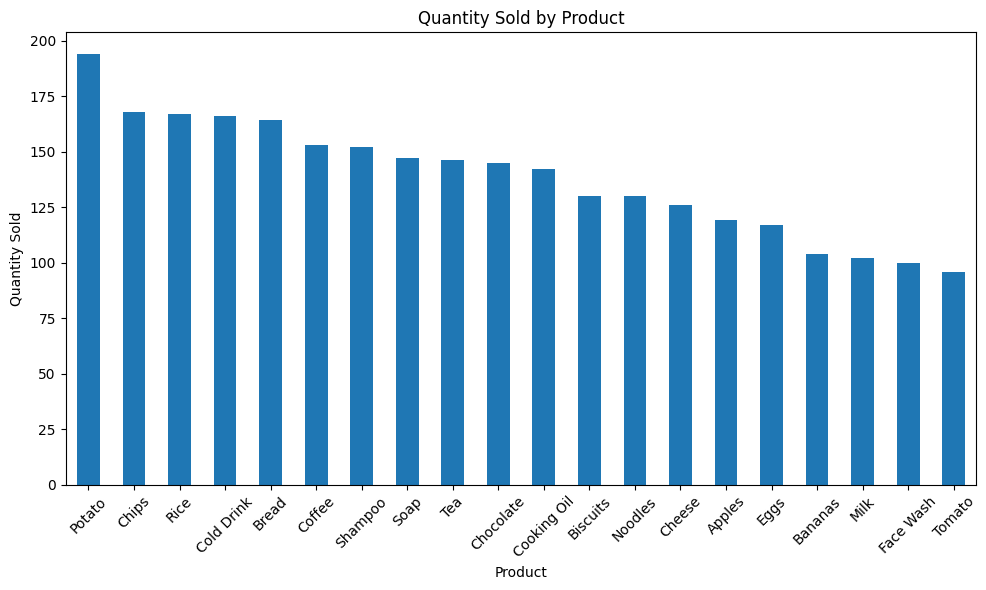

In [39]:
plt.figure(figsize=(10, 6))

quantity_by_product.plot(kind="bar")

plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [40]:
correlation = df[
    [
        "Quantity",
        "Unit Price",
        "Rating",
        "Sales"
    ]
].corr()

print(correlation)

            Quantity  Unit Price    Rating     Sales
Quantity    1.000000   -0.012187  0.000971  0.573160
Unit Price -0.012187    1.000000 -0.088855  0.722365
Rating      0.000971   -0.088855  1.000000 -0.046572
Sales       0.573160    0.722365 -0.046572  1.000000


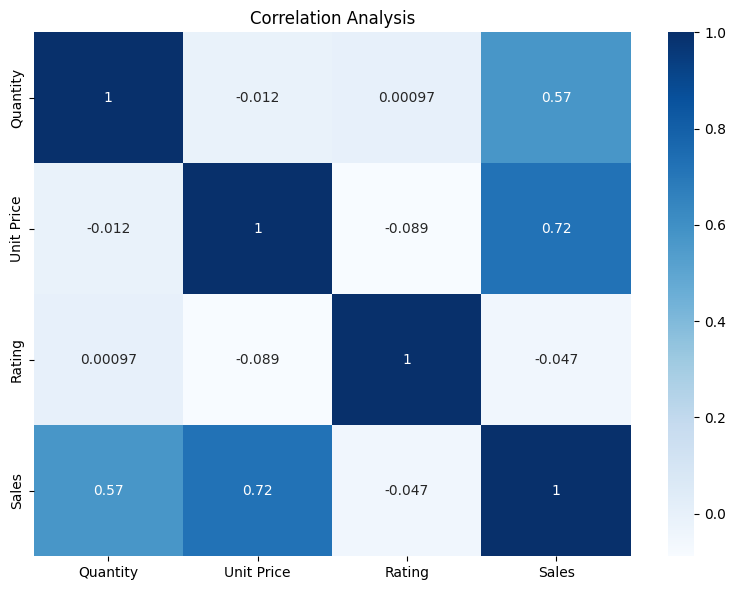

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns  # Add this import line

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="Blues")
plt.title("Correlation Analysis")
plt.tight_layout()
plt.show()

In [44]:
summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Transactions",
        "Total Quantity Sold",
        "Average Transaction",
        "Average Rating",
        "Top Product",
        "Best Branch",
        "Top Category",
        "Most Used Payment"
    ],
    
    "Value": [
        f"₹{total_sales:,.2f}",
        total_transactions,
        total_quantity,
        f"₹{average_transaction:,.2f}",
        round(average_rating, 2),
        top_product,
        best_branch,
        top_category,
        popular_payment
    ]
})

summary

,Metric,Value
0,Total Sales,"₹244,411.08"
1,Total Transactions,500
2,Total Quantity Sold,2768
3,Average Transaction,₹488.82
4,Average Rating,3.99
5,Top Product,Cheese
6,Best Branch,C
7,Top Category,Beverages
8,Most Used Payment,UPI


In [45]:
print("========== BUSINESS INSIGHTS ==========")

print(f"1. Total sales generated: ₹{total_sales:,.2f}")

print(
    f"2. {top_product} generated the highest "
    f"sales among products."
)

print(
    f"3. Branch {best_branch} generated the highest "
    f"branch sales."
)

print(
    f"4. {top_category} was the highest-selling "
    f"category."
)

print(
    f"5. {popular_payment} was the most-used "
    f"payment method."
)

print(
    f"6. The average customer rating was "
    f"{average_rating:.2f}/5."
)

print(
    "7. High-selling products should be maintained "
    "with sufficient inventory."
)

print(
    "8. Branch performance can be studied to "
    "understand successful sales patterns."
)

print(
    "9. Popular payment methods should continue "
    "to be supported."
)

========== BUSINESS INSIGHTS ==========
1. Total sales generated: ₹244,411.08
2. Cheese generated the highest sales among products.
3. Branch C generated the highest branch sales.
4. Beverages was the highest-selling category.
5. UPI was the most-used payment method.
6. The average customer rating was 3.99/5.
7. High-selling products should be maintained with sufficient inventory.
8. Branch performance can be studied to understand successful sales patterns.
9. Popular payment methods should continue to be supported.
